# YouTube Analytics — Prédiction de Performance

**Objectif** : prédire le nombre de vues d'une vidéo YouTube à partir de ses caractéristiques et de sa performance des 7 premiers jours.

Ce notebook suit toutes les étapes du projet :
1. Chargement et nettoyage des données
2. Analyse exploratoire (EDA)
3. Préparation du dataset (feature engineering)
4. Modélisation — version 1 (avec fuite de données)
5. Modélisation — version 2 (corrigée, honnête)
6. Comparaison et conclusion


## 0. Installation & imports

In [ ]:
# !pip install pandas numpy scikit-learn joblib matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

pd.set_option('display.max_columns', 20)
plt.rcParams['figure.dpi'] = 100

## 1. Chargement et nettoyage des données

On charge les 4 fichiers et on corrige les problèmes identifiés :
- Ligne "Total" à exclure dans `Aggregated_Metrics_By_Video`
- Caractères invisibles dans les noms de colonnes
- Espaces parasites dans les IDs vidéo
- Formats de dates hétérogènes (`"Sept"` → `"Sep"`)


In [10]:
RAW = "raw"

by_video = pd.read_csv(f"{RAW}/Aggregated_Metrics_By_Video.csv")
by_video.columns = [c.replace('\xad', '') for c in by_video.columns]
by_video['Video'] = by_video['Video'].str.strip()
by_video = by_video[by_video['Video'] != 'Total'].copy()
by_video['pub_dt'] = pd.to_datetime(by_video['Video publish time'], format='%b %d, %Y', errors='coerce')

print("Aggregated_Metrics_By_Video :", by_video.shape)
by_video.head(3)

Aggregated_Metrics_By_Video : (223, 20)


,Video,Video title,Video publish time,Comments added,Shares,Dislikes,Likes,Subscribers lost,Subscribers gained,RPM (USD),CPM (USD),Average percentage viewed (%),Average view duration,Views,Watch time (hours),Subscribers,Your estimated revenue (USD),Impressions,Impressions click-through rate (%),pub_dt
1,4OZip0cgOho,How I Would Learn Data Science (If I Had to St...,"May 8, 2020",907,9583,942,46903,451,46904,6.353,12.835,36.65,0:03:09,1253559,65850.7042,46453,7959.533,26498799,3.14,2020-05-08
2,78LjdAAw0wA,100K Channel Update + AMA Stream!,"Nov 12, 2020",412,4,4,130,15,12,2.668,6.259,6.26,0:05:14,2291,200.2966,-3,6.113,188318,0.72,2020-11-12
3,hO_YKK_0Qck,Uber Driver to Machine Learning Engineer in 9 ...,"Jul 16, 2020",402,152,15,881,9,198,9.516,11.695,15.12,0:10:21,21350,3687.3387,189,202.963,442334,2.53,2020-07-16


In [11]:
country = pd.read_csv(f"{RAW}/Aggregated_Metrics_By_Country_And_Subscriber_Status.csv")
print("Country/Subscriber :", country.shape)
country.head(3)


Country/Subscriber : (55292, 15)


,Video Title,External Video ID,Video Length,Thumbnail link,Country Code,Is Subscribed,Views,Video Likes Added,Video Dislikes Added,Video Likes Removed,User Subscriptions Added,User Subscriptions Removed,Average View Percentage,Average Watch Time,User Comments Added
0,🌶 Hot Topics in Tech: Data Science Explained #...,OtqQYqRNDGI,59,https://i.ytimg.com/vi/OtqQYqRNDGI/hqdefault.jpg,HK,True,23,1,0,0,2,0,0.67187,39.640348,0
1,🌶 Hot Topics in Tech: Data Science Explained #...,OtqQYqRNDGI,59,https://i.ytimg.com/vi/OtqQYqRNDGI/hqdefault.jpg,ME,True,3,0,0,0,0,0,0.49887,29.433333,0
2,🌶 Hot Topics in Tech: Data Science Explained #...,OtqQYqRNDGI,59,https://i.ytimg.com/vi/OtqQYqRNDGI/hqdefault.jpg,RW,True,2,0,0,0,0,0,0.68178,40.225000,0


In [12]:
comments = pd.read_csv(f"{RAW}/All_Comments_Final.csv")
comments['Date'] = pd.to_datetime(comments['Date'], errors='coerce')
print("Comments :", comments.shape)
comments.head(3)


Comments : (10240, 7)


,Comments,Comment_ID,Reply_Count,Like_Count,Date,VidId,user_ID
0,Thanks for this video Ken.\n\nI decided to go ...,UgxFZTIzC4UPyhhX_PZ4AaABAg,0,0,2022-01-22 08:13:29+00:00,xpIFS6jZbe8,user_981
1,Hello ken jee!!! I'm doing a graduation on Com...,Ugx3IYuAufhb932GYQx4AaABAg,0,0,2022-01-22 01:09:46+00:00,xpIFS6jZbe8,user_213
2,"Thanks for this video, man. So useful. I'll me...",UgyhwwoK24arzRt1mud4AaABAg,0,0,2022-01-21 23:59:05+00:00,rEWPqw6rMGI,user_1065


In [13]:
perf = pd.read_csv(f"{RAW}/Video_Performance_Over_Time.csv")
perf['Date'] = pd.to_datetime(perf['Date'].str.replace('Sept', 'Sep'), format='%d %b %Y', errors='coerce')
print("Performance over time :", perf.shape)
perf.head(3)


Performance over time : (111857, 14)


,Date,Video Title,External Video ID,Video Length,Thumbnail link,Views,Video Likes Added,Video Dislikes Added,Video Likes Removed,User Subscriptions Added,User Subscriptions Removed,Average View Percentage,Average Watch Time,User Comments Added
0,2022-01-19,Kaggle Project From Scratch - Part 2 (Explorat...,KQ80oD_boBM,2191,https://i.ytimg.com/vi/KQ80oD_boBM/hqdefault.jpg,13,0,0,0,0,0,0.069055,151.300154,0
1,2022-01-19,Welcome To My Channel | Ken Jee | Data Science,smeFkHwnM_k,51,https://i.ytimg.com/vi/smeFkHwnM_k/hqdefault.jpg,2,0,0,0,1,0,0.471255,24.034000,0
2,2022-01-19,How She Dominated the FAANG Data Science Inter...,vfV4nm004VQ,2686,https://i.ytimg.com/vi/vfV4nm004VQ/hqdefault.jpg,10,0,0,0,0,0,0.126049,338.567500,0


## 2. Analyse exploratoire (EDA)

Quelques visualisations clés pour comprendre les données avant de construire le modèle.


### 2.1 Distribution des vues par vidéo

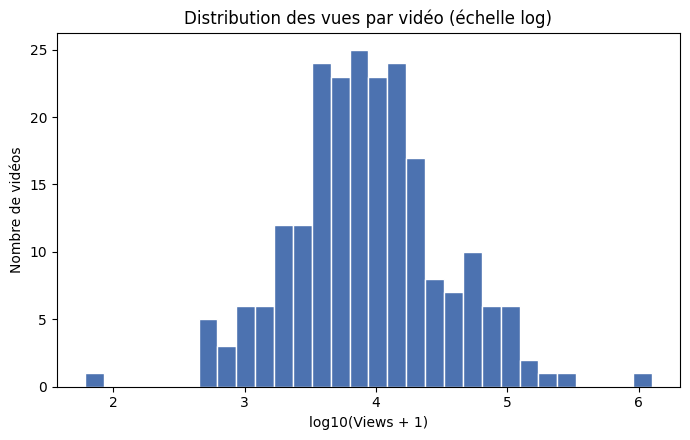

In [14]:
fig, ax = plt.subplots(figsize=(7,4.5))
ax.hist(np.log10(by_video['Views']+1), bins=30, color='#4C72B0', edgecolor='white')
ax.set_xlabel('log10(Views + 1)')
ax.set_ylabel("Nombre de vidéos")
ax.set_title('Distribution des vues par vidéo (échelle log)')
plt.tight_layout()
plt.show()


**Lecture** : distribution très asymétrique (loi de puissance) — quelques vidéos font l'essentiel des vues. On travaillera donc en `log(views)` pour la modélisation.

### 2.2 Top 10 vidéos par vues

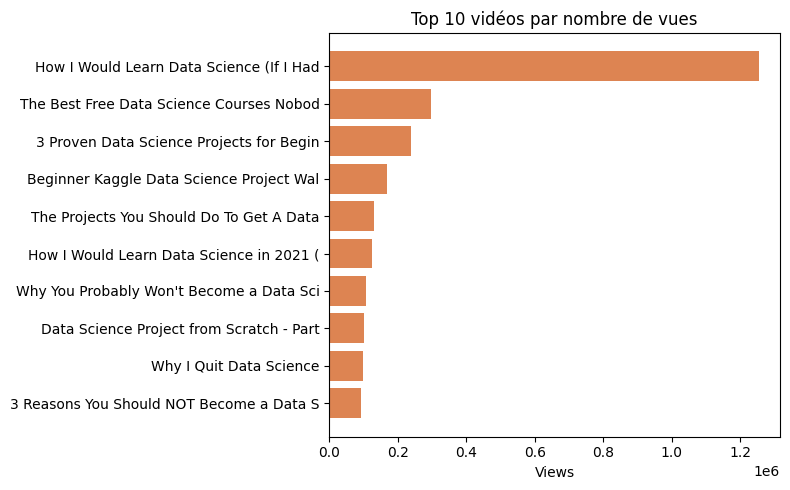

In [ ]:
top10 = by_video.nlargest(10, 'Views')[['Video title','Views']]
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(top10['Video title'].str[:40][::-1], top10['Views'][::-1], color='#DD8452')
ax.set_xlabel('Views')
ax.set_title('Top 10 vidéos par nombre de vues')
plt.tight_layout()
plt.show()

### 2.3 Corrélations entre métriques

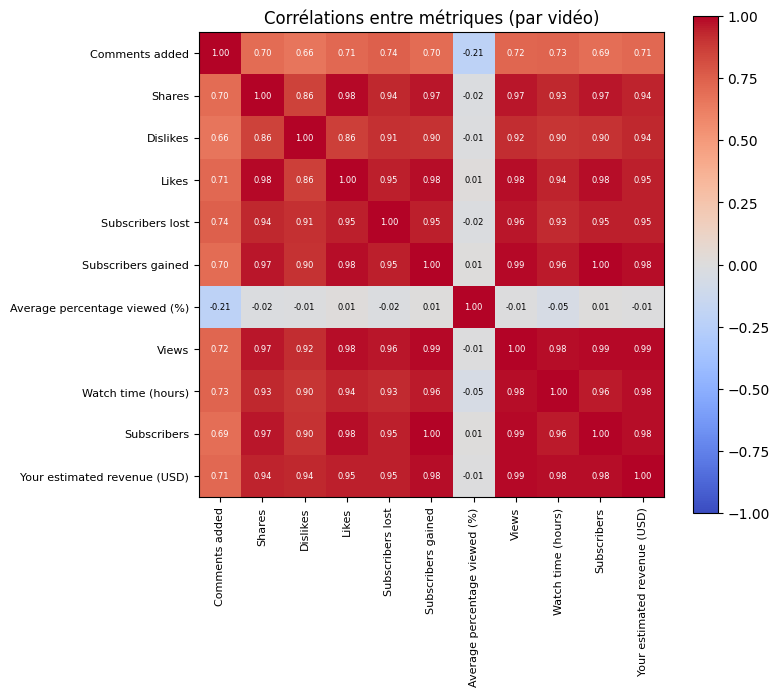

In [ ]:
num_cols = ['Comments added','Shares','Dislikes','Likes',
            'Subscribers lost','Subscribers gained','Average percentage viewed (%)',
            'Views','Watch time (hours)','Subscribers','Your estimated revenue (USD)']
corr = by_video[num_cols].corr()

fig, ax = plt.subplots(figsize=(8,7))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=90, fontsize=8)
ax.set_yticklabels(num_cols, fontsize=8)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j,i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=6,
                color='white' if abs(corr.iloc[i,j])>0.5 else 'black')
plt.colorbar(im)
ax.set_title('Corrélations entre métriques (par vidéo)')
plt.tight_layout()
plt.show()

## 3. Préparation du dataset (feature engineering)

On construit un dataset à 1 ligne = 1 vidéo, avec :
- Métadonnées de publication (jour, mois)
- Durée de la vidéo
- Portée géographique (`n_countries`) —  variable à risque de fuite, gardée pour comparaison
- Part de vues issue des abonnés (`subscribed_share`)
- Performance des 7 premiers jours (`views_7d`, `likes_7d`, `comments_7d`, `avg_view_pct_7d`)
- Volume total de commentaires (`n_comments_total`) — également à risque de fuite


In [ ]:
feats = by_video[['Video', 'Video title', 'pub_dt']].copy()
feats = feats.merge(by_video[['Video', 'Views']], on='Video')
feats['log_views'] = np.log1p(feats['Views'])

feats['pub_dow'] = feats['pub_dt'].dt.dayofweek
feats['pub_month'] = feats['pub_dt'].dt.month
feats['pub_year'] = feats['pub_dt'].dt.year

length = country.groupby('External Video ID')['Video Length'].first()
feats = feats.merge(length.rename('video_length'), left_on='Video', right_index=True, how='left')

reach = country[country['Views'] > 0].groupby('External Video ID')['Country Code'].nunique()
feats = feats.merge(reach.rename('n_countries'), left_on='Video', right_index=True, how='left')
feats['n_countries'] = feats['n_countries'].fillna(0)

sub_share = country.groupby(['External Video ID', 'Is Subscribed'])['Views'].sum().unstack(fill_value=0)
sub_share['subscribed_share'] = sub_share.get(True, 0) / (sub_share.sum(axis=1).replace(0, np.nan))
feats = feats.merge(sub_share['subscribed_share'], left_on='Video', right_index=True, how='left')
feats['subscribed_share'] = feats['subscribed_share'].fillna(0)

perf_v = perf.merge(feats[['Video', 'pub_dt']], left_on='External Video ID', right_on='Video', how='inner')
perf_v['days_since_pub'] = (perf_v['Date'] - perf_v['pub_dt']).dt.days
early = perf_v[(perf_v['days_since_pub'] >= 0) & (perf_v['days_since_pub'] <= 7)]
early_agg = early.groupby('External Video ID').agg(
    views_7d=('Views', 'sum'),
    likes_7d=('Video Likes Added', 'sum'),
    comments_7d=('User Comments Added', 'sum'),
    avg_view_pct_7d=('Average View Percentage', 'mean'),
)
feats = feats.merge(early_agg, left_on='Video', right_index=True, how='left')

n_comments = comments.groupby('VidId').size()
feats = feats.merge(n_comments.rename('n_comments_total'), left_on='Video', right_index=True, how='left')
feats['n_comments_total'] = feats['n_comments_total'].fillna(0)

feats = feats.dropna(subset=['views_7d', 'video_length', 'pub_dt'])
print("Dataset final :", feats.shape)
feats.to_csv("data/processed/dataset_model.csv", index=False)
feats.head()

Dataset final : (222, 16)


,Video,Video title,pub_dt,Views,log_views,pub_dow,pub_month,pub_year,video_length,n_countries,subscribed_share,views_7d,likes_7d,comments_7d,avg_view_pct_7d,n_comments_total
0,4OZip0cgOho,How I Would Learn Data Science (If I Had to St...,2020-05-08,1253559,14.041498,4,5,2020,516,226,0.068133,121456.0,5182.0,0.0,0.339556,797.0
1,78LjdAAw0wA,100K Channel Update + AMA Stream!,2020-11-12,2291,7.737180,3,11,2020,5029,110,0.737669,1947.0,120.0,0.0,0.072965,12.0
2,hO_YKK_0Qck,Uber Driver to Machine Learning Engineer in 9 ...,2020-07-16,21350,9.968854,3,7,2020,4112,163,0.531649,3736.0,208.0,0.0,0.149609,49.0
3,uXLnbdHMf8w,Why I'm Starting Data Science Over Again.,2020-08-29,49564,10.811040,5,8,2020,467,177,0.365262,26867.0,2014.0,0.0,0.348243,192.0
4,Xgg7dIKys9E,Interview with the Director of AI Research @ N...,2020-08-05,13429,9.505246,2,8,2020,2904,151,0.441391,7974.0,405.0,0.0,0.090744,42.0


## 4. Modélisation — Version 1 ( avec fuite de données)

On entraîne un premier modèle avec **toutes** les variables, y compris `n_countries` et `n_comments_total`.


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

FEATURES_V1 = ['video_length', 'pub_dow', 'pub_month', 'n_countries',
               'subscribed_share', 'views_7d', 'likes_7d', 'comments_7d',
               'avg_view_pct_7d', 'n_comments_total']
TARGET = 'log_views'

X = feats[FEATURES_V1].fillna(0)
y = feats[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_v1 = LinearRegression().fit(X_train, y_train)
rf_v1 = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42).fit(X_train, y_train)

pred_lr = lr_v1.predict(X_test)
pred_rf = rf_v1.predict(X_test)

results_v1 = pd.DataFrame({
    'LinearRegression': [mean_absolute_error(y_test, pred_lr), mean_squared_error(y_test, pred_lr)**0.5, r2_score(y_test, pred_lr)],
    'RandomForest': [mean_absolute_error(y_test, pred_rf), mean_squared_error(y_test, pred_rf)**0.5, r2_score(y_test, pred_rf)],
}, index=['MAE', 'RMSE', 'R2'])

results_v1

,LinearRegression,RandomForest
MAE,0.245505,0.240066
RMSE,0.308693,0.312418
R2,0.927912,0.926162


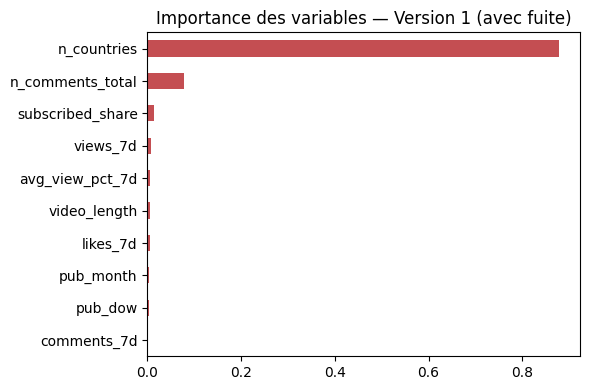

n_countries         0.879321
n_comments_total    0.077576
subscribed_share    0.014250
views_7d            0.006584
avg_view_pct_7d     0.005508
video_length        0.004968
likes_7d            0.004452
pub_month           0.004185
pub_dow             0.003157
comments_7d         0.000000
dtype: float64

In [ ]:
importance_v1 = pd.Series(rf_v1.feature_importances_, index=FEATURES_V1).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6,4))
importance_v1.sort_values().plot.barh(ax=ax, color="#C44E52")
ax.set_title("Importance des variables — Version 1 (avec fuite)")
plt.tight_layout()
plt.show()
importance_v1

**Constat** : R² très élevé (~0.93), mais `n_countries` domine à ~88% l'importance. Cette variable est calculée sur toute la vie de la vidéo, donc quasiment équivalente à la cible → **fuite de données**. Ce résultat n'est pas fiable pour un usage prédictif réel.

## 5. Modélisation — Version 2 (corrigée, sans fuite)

On retire `n_countries` et `n_comments_total`. Seules les variables disponibles **7 jours après publication** sont conservées — c'est le scénario réaliste d'une prédiction précoce.


In [25]:
FEATURES_V2 = ['video_length', 'pub_dow', 'pub_month', 'subscribed_share',
               'views_7d', 'likes_7d', 'comments_7d', 'avg_view_pct_7d']

X2 = feats[FEATURES_V2].fillna(0)
y2 = feats[TARGET]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

lr_v2 = LinearRegression().fit(X2_train, y2_train)
rf_v2 = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42).fit(X2_train, y2_train)

pred_lr2 = lr_v2.predict(X2_test)
pred_rf2 = rf_v2.predict(X2_test)

results_v2 = pd.DataFrame({
    'LinearRegression': [mean_absolute_error(y2_test, pred_lr2), mean_squared_error(y2_test, pred_lr2)**0.5, r2_score(y2_test, pred_lr2)],
    'RandomForest': [mean_absolute_error(y2_test, pred_rf2), mean_squared_error(y2_test, pred_rf2)**0.5, r2_score(y2_test, pred_rf2)],
}, index=['MAE', 'RMSE', 'R2'])

results_v2


,LinearRegression,RandomForest
MAE,0.686592,0.455733
RMSE,0.880874,0.695819
R2,0.413003,0.633730


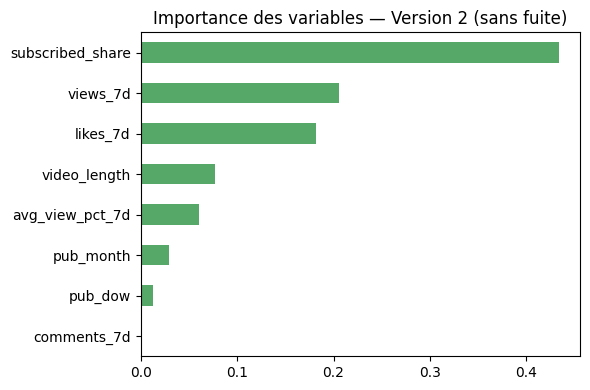

subscribed_share    0.433804
views_7d            0.205719
likes_7d            0.182058
video_length        0.076875
avg_view_pct_7d     0.060042
pub_month           0.028960
pub_dow             0.012543
comments_7d         0.000000
dtype: float64

In [26]:
importance_v2 = pd.Series(rf_v2.feature_importances_, index=FEATURES_V2).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6,4))
importance_v2.sort_values().plot.barh(ax=ax, color="#55A868")
ax.set_title("Importance des variables — Version 2 (sans fuite)")
plt.tight_layout()
plt.show()
importance_v2


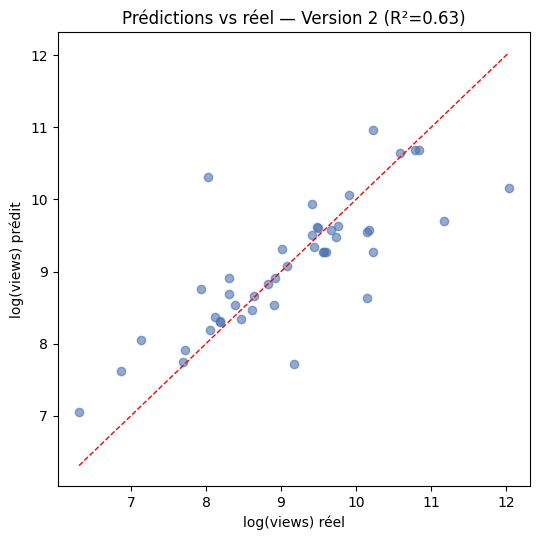

In [27]:
fig, ax = plt.subplots(figsize=(5.5,5.5))
ax.scatter(y2_test, pred_rf2, alpha=0.6, color="#4C72B0")
lims = [min(y2_test.min(), pred_rf2.min()), max(y2_test.max(), pred_rf2.max())]
ax.plot(lims, lims, 'r--', lw=1)
ax.set_xlabel("log(views) réel")
ax.set_ylabel("log(views) prédit")
ax.set_title(f"Prédictions vs réel — Version 2 (R²={r2_score(y2_test, pred_rf2):.2f})")
plt.tight_layout()
plt.show()


## 6. Comparaison et conclusion

| | Version 1 (avec fuite) | Version 2 (honnête) |
|---|---|---|
| R² | ~0.93 | ~0.63 |
| Variable dominante | `n_countries` (fuite) | `subscribed_share`, `views_7d`, `likes_7d` |
| Fiable pour la prédiction précoce ? | ❌ Non | ✅ Oui |

**Conclusion** : le modèle Version 2 est le seul valide pour un cas d'usage réel (prédire tôt, avant que la vidéo n'ait fini sa vie). Il explique ~63% de la variance des vues à partir des 7 premiers jours — un socle correct à améliorer par la suite (tuning des hyperparamètres, plus de données, variables supplémentaires sur les commentaires/sentiment).

### Prochaines étapes possibles
- Tuning des hyperparamètres (`GridSearchCV`)
- Validation croisée pour un score plus robuste
- Ajout de variables sur le sentiment des commentaires
- Test d'un modèle de séries temporelles pur (prédire jour par jour)


In [29]:
import os
os.makedirs("models", exist_ok=True)

joblib.dump(rf_v2, "models/best_model_v2.pkl")
print("Modèle final sauvegardé : models/best_model_v2.pkl")

Modèle final sauvegardé : models/best_model_v2.pkl


In [30]:
joblib.dump(rf_v2, "models/best_model_v2.pkl")
print("Modèle final sauvegardé : models/best_model_v2.pkl")

Modèle final sauvegardé : models/best_model_v2.pkl
